# Campaign for selling personal loans.

##### This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

##### The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

##### The file Bank.xls contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

## DataSet Description: 
#### ID - Customer ID
#### Age - Customer's age in completed years
#### Experience - Number years of professional experience
#### Income - Annual income of the customer (US Dollars)
#### ZIPCode - Home Address ZIP code.
#### Family - Family size of the customer
#### CCAvg - Avg. spending on credit cards per month (US Dollars)
#### Education - Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional
#### Mortgage - Value of house mortgage if any. (US Dollars)
#### Personal Loan - Did this customer accept the personal loan offered in the last campaign?
#### Securities Account - Does the customer have a securities account with the bank?
#### CD Account - Does the customer have a certificate of deposit (CD) account with the bank?
#### Online - Does the customer use internet banking facilities?
#### CreditCard - Does the customer use a credit card issued by UniversalBank?

## Task 1: Data Loading  (5 Marks)
Perform the following tasks

1. Import the necessary libraries required
2. Read the csv into a dataframe
3. Display the first five rows of your dataframe.
4. Display the datatypes of the columns
5. Display the column names in the dataframe

### 1.1 Importing Libraries

In [2]:
# Import the necessary libraries required
import os

# data manipulation 
import pandas as pd
import numpy as np

# deep learning tools
import tensorflow as tf
import keras_tuner as kt

# ML algorithms
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.tree import DecisionTreeClassifier

# feature engineering tools
from scipy.stats import pearsonr
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer

# algorithm metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV , StratifiedKFold
from sklearn.pipeline import Pipeline
import joblib

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 1.2 Read dataframe

In [3]:
# Read the csv into a dataframe
personal_loan_df = pd.read_csv('../data/Bank_Personal_Loan_Modelling-1.csv')

pd.set_option('display.max_columns', None)

### 1.3 Display 1st 5 rows

In [4]:
# Display the first five rows of your dataframe.
personal_loan_df.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### 1.4 Dtypes of the columns

In [5]:
# Display the datatypes of the columns
personal_loan_df.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

### 1.5 Column Names of the df

In [6]:
# Display the column names in the dataframe
print(list(personal_loan_df.columns))

['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


## Task 2: Data Cleaning (10 Marks)

1. Drop the unnecessary columns in the dataframe(i.e. 'ID'). <b>(2Marks)</b>
2. Check for missing values in the dataframe and display the count in ascending order. Impute the missing values. <b>(2Marks)</b>
3. Check whether there are any duplicate values in the dataframe and if present remove them. <b>(2Marks)</b>
4. Display the total number of records in the dataframe after removing the duplicates. <b>(2Marks)</b>
5. Create a 5 Point summary of the data. <b>(2Marks)</b>

### 2.1 Unnecessary column drops

In [7]:
# Drop the unnecessary columns in the dataframe(i.e. 'ID')
personal_loan_df.drop(columns={"ID"},axis=1, inplace=True)

### 2.2 Handling missing Values

In [8]:
# a function for handling missing values
def missing_Val(df):
    # if df is a dataframe
    if isinstance(df, pd.DataFrame):
        missing_count = df.isna().sum().sum()
    # if df is a series
    elif isinstance(df, pd.Series):
        missing_count = df.isna().sum()
    # if df id neither dataframe or a series
    else:
        print("err! : not a valid data type")
        exit() 

    if missing_count == 0:
        state = False
        print(f"{state}, no missing values present")
    else:
        state = True
        print(f"{state}, {missing_count} - Missing Values")

In [9]:
missing_Val(personal_loan_df)

False, no missing values present


In [10]:
# Check for missing values in the dataframe and display the count in ascending order. Impute the missing values
missing_Val(personal_loan_df)

False, no missing values present


### 2.3 Check for duplicates

In [11]:
personal_loan_df.shape

(5000, 13)

In [12]:
# Check whether there are any duplicate values in the dataframe and if present remove them
print(personal_loan_df.duplicated().sum())

0


### 2.4 Total No.Of records in df

In [13]:
# Display the total number of records in the dataframe after removing the duplicates.
personal_loan_df.drop_duplicates(inplace=True)
print(personal_loan_df.duplicated().sum())

0


In [14]:
personal_loan_df.shape

(5000, 13)

* Since, there were no duplicate found , it's still 5000 records

### 2.5 Five Point Summary of the Data

In [15]:
personal_loan_df.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [16]:
personal_loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


In [17]:
df_col_ls = personal_loan_df.columns.tolist()
df_col_ls

for i in df_col_ls:
    print(f"{i}, Unique Values: \n {personal_loan_df[i].unique()}")

Age, Unique Values: 
 [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
Experience, Unique Values: 
 [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
Income, Unique Values: 
 [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 1

In [18]:
# Create a 5 Point summary of the data

5 Point Summary of the Dataset (Personal Loan)
* This dataset contains 5000 records
* Binary Features => [`Personal Loan`,`Securities Account`,`CD Account`,`Online`,`Credit Card`]  ('0' or '1').
* Numerical and Non-Continous Values => [`Income`,`ZIP Code`,`CCAVG`,`Mortgage`]
* Multi-Categorical Values => [`Age`,`Family`,`Education`]
* Initially there were no Null or Duplicate Values found.

## Task 3: Data Analysis and Visualization (20Marks)

1. Check for correlation of the attributes in the dataframe and plot the heatmap for the same. <b>(4Marks)</b>
2. Plot a pairplot for the attributes. Use "Personal Loan" as hue. <b>(4Marks)</b>
3. From the above visualization identify the attributes that are correlated and drop the unnecessary attribute(column) <b>(4Marks)</b> 
4. Plot a boxplot to understand the distribution of data for the attributes such as "Age", "Income", Family", "CCAvg", "Education", "Mortgage" by taking x axis as "Personal Loan" <b>(4Marks)</b> 
5. Display the unique values of attributes "Family", "Education" and "Personal loan" and plot a bargraph. <b>(4Marks)</b>

CLEAN → `(VISUALIZE)` → FEATURE ENG → (TEMPORARY SCALE → CORRELATION / RFECV) 
→ SPLIT DATA → APPLY SMOTE (train only) → SCALE (fit on train) → FINAL TRAINING 
→ OPTIMIZE → EVALUATE → DEPLOY

### 3.1 Visualization

#### 3.1.1 Correlation and Heatmap

In [19]:
personal_loan_df.corr()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities Account,-0.000436,-0.001232,-0.002616,0.004704,0.019994,0.015086,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028


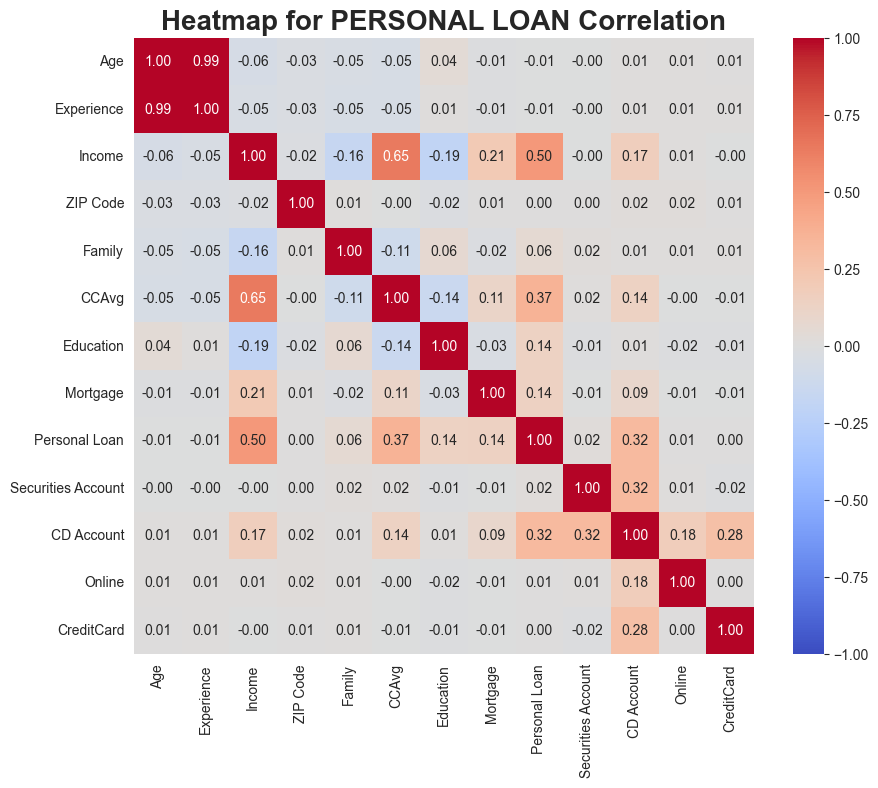

<Figure size 640x480 with 0 Axes>

In [20]:
# Check for correlation of the attributes in the dataframe and plot the heatmap for the same.

plt.figure(figsize = (10,8))

sns.heatmap(personal_loan_df.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm" , fmt=".2f")

plt.title("Heatmap for PERSONAL LOAN Correlation",fontweight="bold", fontsize=20)

plt.show()

plt.savefig("../visualization/heatmap.png")

#### 3.1.2 Pairplot 

<Figure size 1500x2000 with 0 Axes>

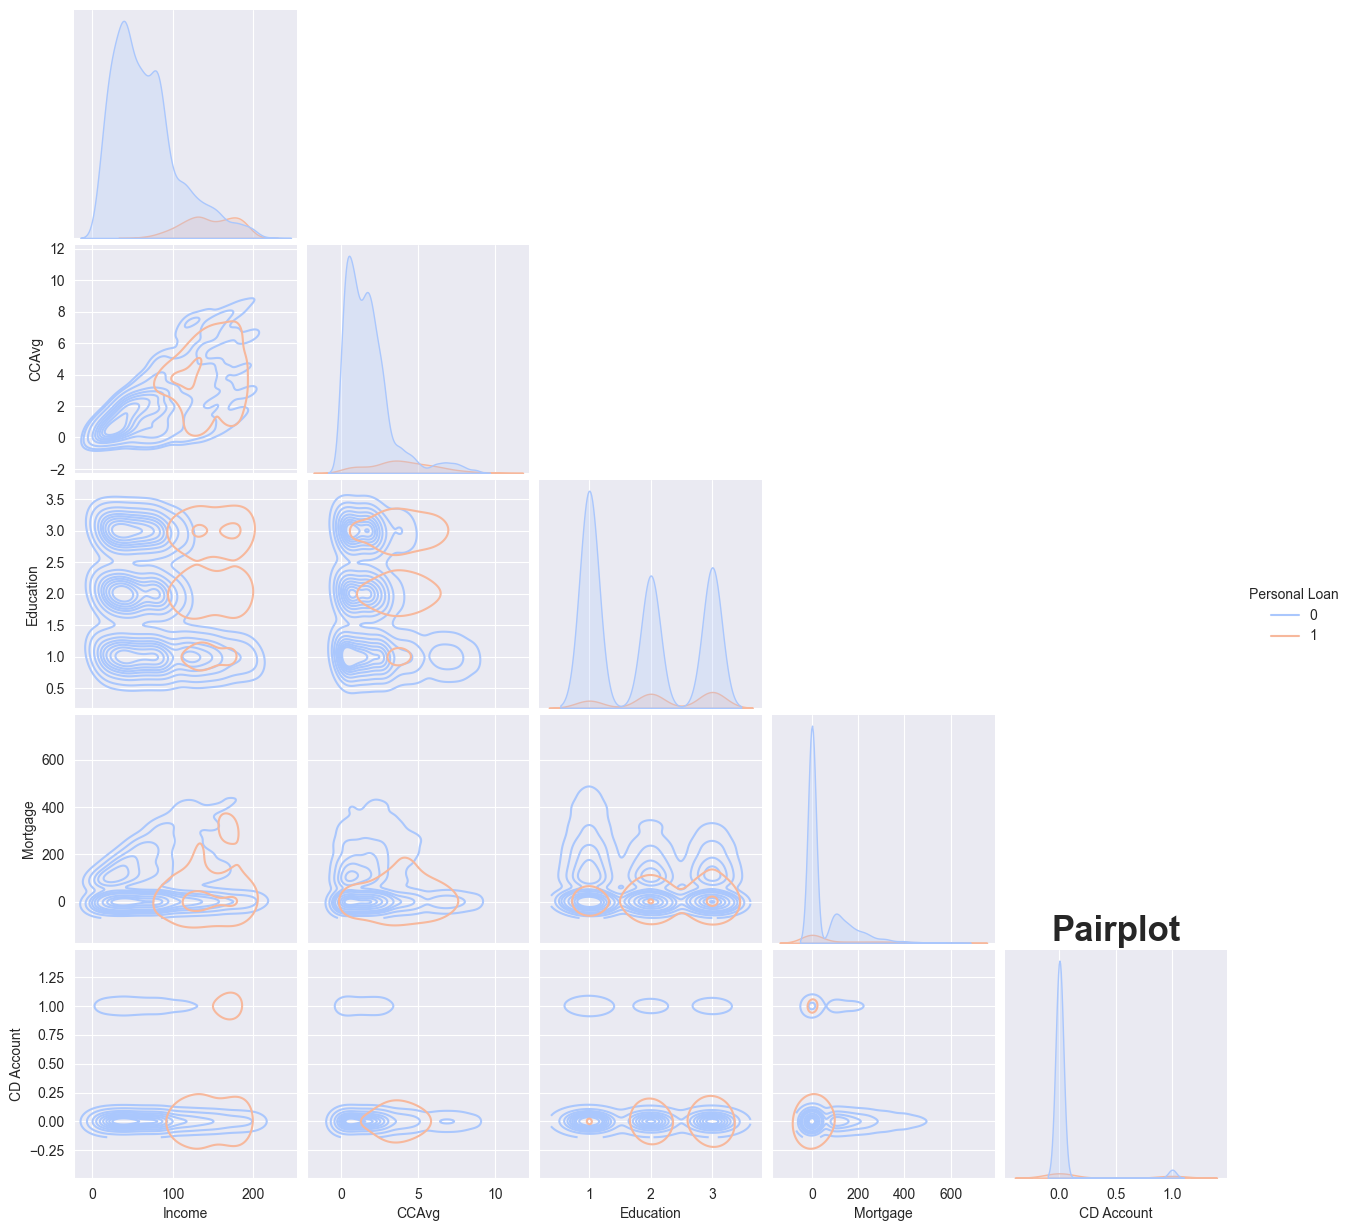

<Figure size 640x480 with 0 Axes>

In [21]:
# Plot a pairplot for the attributes. Use "Personal Loan" as hue. 

plt.figure(figsize=(15,20))

sns.pairplot(
    data = personal_loan_df, hue = "Personal Loan", palette = "coolwarm", kind = "kde",
    x_vars=["Income","CCAvg","Education","Mortgage","CD Account"],
    y_vars=["Income","CCAvg","Education","Mortgage","CD Account"], corner = True
)

plt.title("Pairplot", fontweight="bold", fontsize=25)

plt.show()

plt.savefig("../visualization/pairplot.png")

#### 3.1.3 Feature Identification

In [22]:
# From the above visualization identify the attributes that are correlated and drop the unnecessary attribute(column)
new_df = personal_loan_df.drop(columns={"Age","Experience","ZIP Code","Online","CreditCard"},axis=1)
new_df.head(5)

,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account
0,49,4,1.6,1,0,0,1,0
1,34,3,1.5,1,0,0,1,0
2,11,1,1.0,1,0,0,0,0
3,100,1,2.7,2,0,0,0,0
4,45,4,1.0,2,0,0,0,0


#### 3.1.4 Boxplot

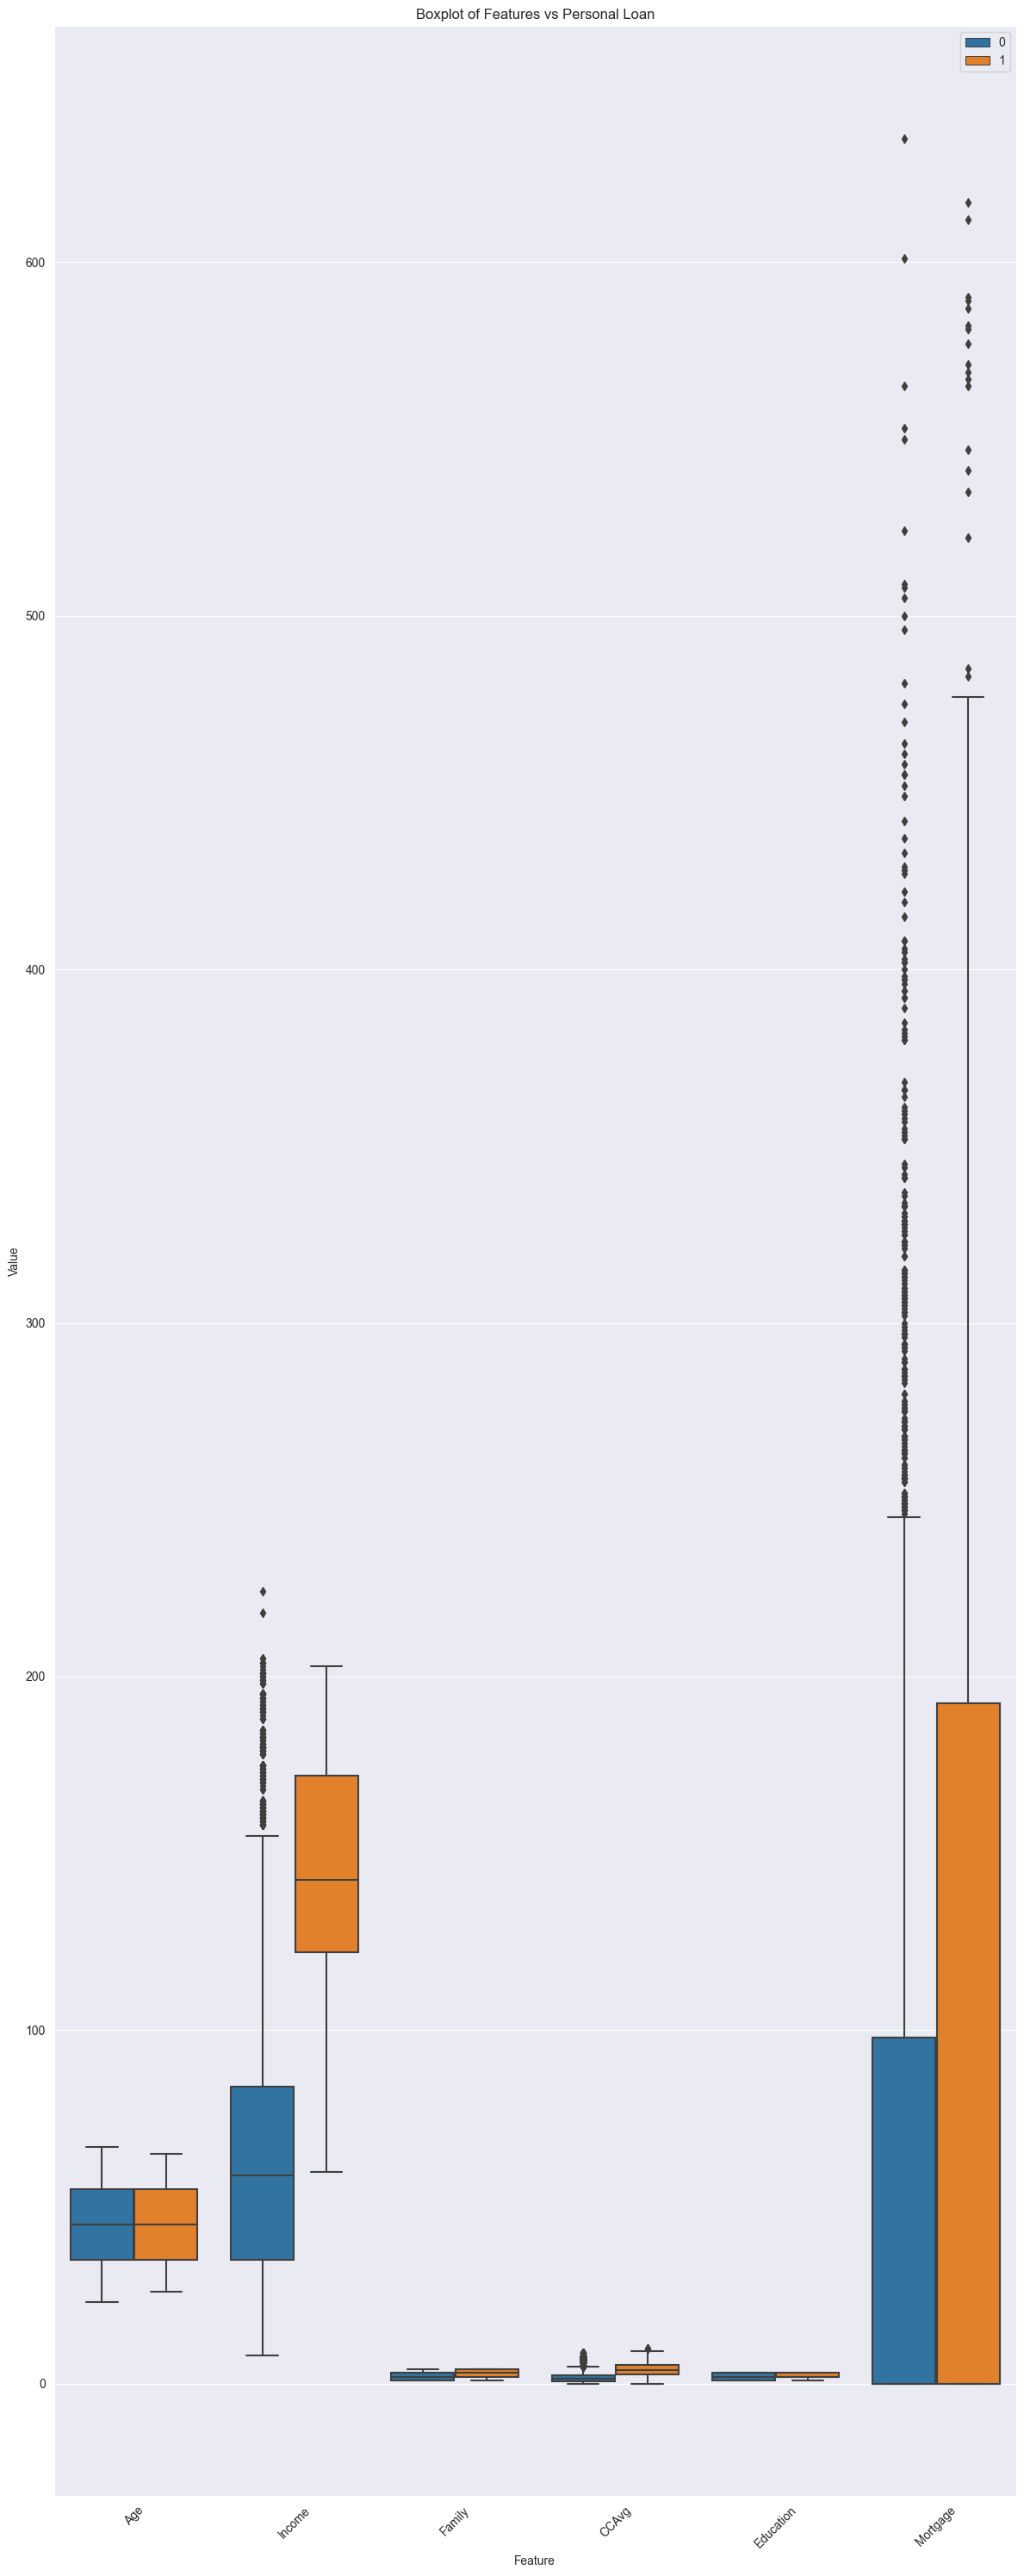

<Figure size 640x480 with 0 Axes>

In [23]:
# Plot a boxplot to understand the distribution of data for the attributes such as "Age", "Income", "Family", "CCAvg", "Education", "Mortgage" by taking x axis as "Personal Loan"

# Select relevant columns
cols = ["Age", "Income", "Family", "CCAvg", "Education", "Mortgage", "Personal Loan"]
df_melted = personal_loan_df[cols].melt(id_vars="Personal Loan", 
                                         var_name="Feature", value_name="Value")

# Create the boxplot
plt.figure(figsize=(12, 30))

sns.boxplot(data=df_melted, x="Feature", y="Value", hue="Personal Loan")

plt.title("Boxplot of Features vs Personal Loan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

plt.savefig("../visualization/boxplots.png")

#### 3.1.5 Bargraph

In [24]:
# Display the unique values of attributes "Family", "Education" and "Personal loan" and plot a bargraph.
ls = ["Family","Education","Personal Loan"]
for i in ls:
    print(f"Unique Values of {i},\n{personal_loan_df[i].unique()}")

Unique Values of Family,
[4 3 1 2]
Unique Values of Education,
[1 2 3]
Unique Values of Personal Loan,
[0 1]


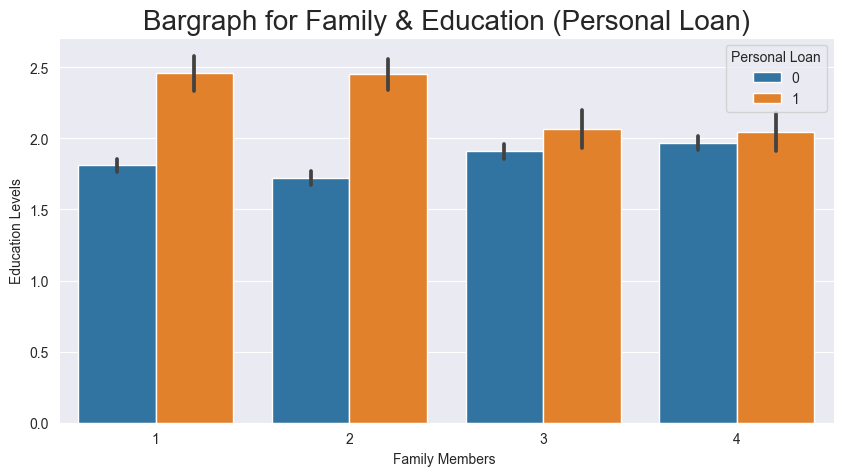

<Figure size 640x480 with 0 Axes>

In [25]:
# bargraph plotting

plt.figure(figsize=(10,5))

sns.barplot(data = personal_loan_df, x="Family",y="Education",hue="Personal Loan")

plt.title("Bargraph for Family & Education (Personal Loan)",fontsize=20)
plt.xlabel("Family Members ", fontsize=10)
plt.ylabel("Education Levels", fontsize=10)
plt.show()

plt.savefig("../visualization/Family Education.png")

In [26]:
personal_loan_df.to_csv("../data/cleaned_data.csv")

### 3.2 Data Analysis

#### 3.2.1 Pearson Correlation

In [27]:
# Finding the best features which has the best correlation to "Personal Loan"
personal_loan_X = personal_loan_df.drop(columns={"Personal Loan"},axis=1)
personal_loan_Y = personal_loan_df["Personal Loan"]

# initializing the variable dictionary
PL_corr = {}
features = list(personal_loan_X.columns)
# print(features)
# inserting elements into the dict
for i in features:
    corr , pval = pearsonr(personal_loan_X[i], personal_loan_Y)
    p_str = str()
    if pval <= 0.0001:
        p_str="strong"
    elif pval<= 0.05:
        p_str="moderate"
    elif pval<=0.1:
        p_str="weak"
    else:
        p_str="No Corr"
    PL_corr[i] = {"corr":corr, "pval":pval, "state":p_str}


PL_corr_df = pd.DataFrame.from_dict(PL_corr)

PL_corr_df = PL_corr_df.transpose()

In [28]:
PL_corr_df.head(6)

,corr,pval,state
Age,-0.007726,0.584959,No Corr
Experience,-0.007413,0.600236,No Corr
Income,0.502462,0.0,strong
ZIP Code,0.000107,0.993944,No Corr
Family,0.061367,0.000014,strong
CCAvg,0.366889,0.0,strong


In [29]:
PL_corr_df.tail(6)

,corr,pval,state
Education,0.136722,0.0,strong
Mortgage,0.142095,0.0,strong
Securities Account,0.021954,0.120621,No Corr
CD Account,0.316355,0.0,strong
Online,0.006278,0.657186,No Corr
CreditCard,0.002802,0.843008,No Corr


* While using `pearsonr` we were able to see only 6 columns with strong correlation with the Personal Loan 
* features Include : [ `Income`, `Family`, `CCAvg`,`Education`,`Mortgage`,`CD Account`]

#### 3.2.2 RFECV Feature Extraction

RFECV - Recursive Feature Elimination with Cross Validation
since RFECV needs a model to perform its duty to find best features 
we will move with 4 basic models:-
* Logistic Regression
* KNN (also not supported)
* SVC (NOt Supported with RFECV)
* Random Forest
* Decision Tree
* Gradient Boosting

In [30]:
# initializing the Models
models = {
    "logR": LogisticRegression(),
    # "SVC" : SVC(kernel='sigmoid', degree=3),
    "RandomForest": RandomForestClassifier(criterion="entropy"),
    # "KNN" : KNeighborsClassifier(n_neighbors=5, algorithm="brute"),
    "DecisionTree": DecisionTreeClassifier(splitter="best"),
    "GradientBoosting" : GradientBoostingClassifier()
}

# intiating cross validation
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

# best features
chosen_features_per_model = {}

# looping through every model
for name , model in models.items():
    # initiating rfecv
    rfecv_model = RFECV(estimator=model , cv=strat_cv, scoring='accuracy', n_jobs=-1)
    
    # fitting the data into the model
    rfecv_model.fit(personal_loan_X , personal_loan_Y)
    
    # choosing the best features
    chosen_features = personal_loan_X.columns[rfecv_model.support_].tolist()
    # feature assignment
    chosen_features_per_model[name] = chosen_features
# 
# # converting the feature dictionary to dataframe
# chosen_features_per_model_df = pd.DataFrame.from_dict(chosen_features_per_model)

F:\SkillUp TechMaster 2024-25\Capstone Project\Personal Loan\Personal Loan\venv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\SkillUp TechMaster 2024-25\Capstone Project\Personal Loan\Personal Loan\venv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternati

In [31]:
tuple(chosen_features_per_model.values())

(['Family',
  'CCAvg',
  'Education',
  'Securities Account',
  'CD Account',
  'Online',
  'CreditCard'],
 ['Age', 'Income', 'Family', 'CCAvg', 'Education', 'CD Account'],
 ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'CD Account'],
 ['Income', 'Family', 'CCAvg', 'Education'])

#### 3.2.3 Extracted Features

From the list provided we can conclude that the features
* Family
* CCAvg
* Education
* Income
* CD Account

These are the essential features for the model. However, we will also include `Mortgage` feature considering the Correlation for the Heatmap as well

In [32]:
# so our new dataset are :-
new_df = personal_loan_df[["Family", "CCAvg", "Education", "Income", "CD Account", "Mortgage", "Personal Loan"]].copy()


#### 3.2.4 Validating the Dataset

In [33]:
# checking for missing values
missing_Val(new_df)

False, no missing values present


In [34]:
# checking for duplicate values
new_df.duplicated().sum()

469

In [35]:
print("Shape of the Data : ",new_df.shape)
print("Number of People who took Personal Loan =>", new_df[new_df["Personal Loan"]==1]["Personal Loan"].value_counts())

Shape of the Data :  (5000, 7)
Number of People who took Personal Loan => 1    480
Name: Personal Loan, dtype: int64


In [36]:
# dropping the duplicated values from the new_data
new_df.drop_duplicates(inplace=True)

In [37]:
print("Shape of the Data : ",new_df.shape)
print("Number of People who took Personal Loan =>", new_df[new_df["Personal Loan"]==1]["Personal Loan"].value_counts())

Shape of the Data :  (4531, 7)
Number of People who took Personal Loan => 1    480
Name: Personal Loan, dtype: int64


In [38]:
new_df.to_csv("../data/final_features_data_df.csv")

## Task 4: Modelling (25Marks)

1. Split data into X and Y. <b>(1Marks)</b>
2. Split the data into training and test set in the ratio of 70:30 respectively <b>(2Marks)</b>
3. Train a Supervised Learning Classification base model using KNN classifier, Naive Bayes and Logistic Regression. Print the train and test accuracy for the same <b>(12Marks)</b>
4. Print the confusion matrix for all the above models <b>(5Marks)</b>
5. Give your reasoning on which is the best model in this case and why it performs better <b>(5Marks)</b>

### 4.1 Split X and y

In [39]:
# Split data into X and Y.
X = new_df.iloc[:,:6]
y = new_df["Personal Loan"]

### 4.2 Split Train & Test set

In [40]:
# Split the data into training and test set in the ratio of 70:30 respectively 
# stratify means it will produce equal distribution on the test set as it did on train set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# checkinng the train and test set shape and size
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape : (3171, 6)
y_train shape : (3171,)
X_test shape : (1360, 6)
y_test shape : (1360,)


#### 4.2.1 Saving the Train and Test Set

In [41]:
# Combine X_train (features) and y_train (target) into one DataFrame
train_set2 = pd.concat([pd.DataFrame(X_train), pd.DataFrame(y_train)], axis=1)
test_set = pd.concat([pd.DataFrame(X_test) , pd.DataFrame(y_test)], axis=1)

# Optional: name the target column properly
train_set2.columns = list(X_train.columns) + ["Personal Loan"]
test_set.columns = list(X_test.columns) + ["Personal Loan"]

# Save to CSV
train_set2.to_csv('../data/biased cleaned data/biased_train_set.csv', index=False)
test_set.to_csv('../data/biased cleaned data/biased_test_set.csv', index=False)


#### 4.2.2 Data Transformation

 * `ColumnTransformation` : Applies different transformations to different columns in a single step.

In [42]:
# Transforming the data train set
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {y_train.shape}")

numerical_cols = ["CCAvg", "Income", "Mortgage"]
categorica_cols = ["Family", "Education", "CD Account"]

# transforming categorical and numerical column with ColumnTransformer, StandardScaler and OneHotEncoding
preprocessing = ColumnTransformer(
    transformers=[
        ('numericals', StandardScaler(), numerical_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorica_cols)
    ]
)

# fit and transform the trainset and just transform the test set
X_train_processed = preprocessing.fit_transform(X_train)
X_test_processed = preprocessing.transform(X_test)



X_train shape : (3171, 6)
X_test shape : (3171,)


In [43]:
joblib.dump(preprocessing,"../models/final_model/column_transformer.pkl")

['../models/final_model/column_transformer.pkl']

In [44]:
X_train_processed.shape

(3171, 12)

#### 4.2.3 SMOTE - Dealing with Minority Set

In [45]:
# Using the Smote() for resolving the imbalance learning from the train set
smt = SMOTE(random_state=333)

# fitting the smote() - Synthetic Minority Oversampling Technique
X_train_resampled , y_train_resampled = smt.fit_resample(X_train_processed, y_train)

# shape and size of the 
print(f"Resampled X_train Shape {X_train_resampled.shape}")
print(f"Resample y_train shape {y_train_resampled.shape}")




Resampled X_train Shape (5670, 12)
Resample y_train shape (5670,)


In [46]:
# number of yes and no
print(f"The number of personal loans (yes) {(y_train_resampled==1).sum()} ")
# number of yes and no
print(f"The number of personal loans (no) {(y_train_resampled==0).sum()} ")

The number of personal loans (yes) 2835 
The number of personal loans (no) 2835 


* Saving the unbiased trainset 


In [47]:
X_train.shape

(3171, 6)

In [48]:
X_train_resampled.shape

(5670, 12)

#### 4.2.4 Saving Unbiased trainset

In [49]:
# gettin features name 
feature_names = preprocessing.get_feature_names_out()

# Combine features + target
X_df = pd.DataFrame(X_train_resampled, columns=feature_names)
y_df = pd.DataFrame(y_train_resampled, columns=["target"])

# Combine into one DataFrame
train_set = pd.concat([X_df, y_df], axis=1)

# Save to CSV
train_set.to_csv("../data/unbiased dataset/unbiased_train_set.csv", index=False)
print("Saved unbiased train set to CSV!")

Saved unbiased train set to CSV!


### 4.3 Model Training (ML)

#### 4.3.1 Models Description (`ML Algo's`)

Machine learning models that are being used are :- 
1. Logistic Regression 
    - a type of regression model that predicts probability
    - Uses `sigmoid` function 
2. SVC
    - Support Vector Classifier uses `Hyperplane` making the boundaries between 2 or more classification.
3. Random Forest Classifiers
    - Decision Trees are the building blocks for RFC and better performer than a single decision tree .
    - focuses on reducing variance by creating diverse, independent models and combining them. 
4. KNearestNeighbour [KNN]
    - Instance Based classifier , chooses neighbours based on the `No.Of neighbours` that you want to choose.
5. RadiusNeighborsClassifier
    - Instance Based Classifier , chooses its neighours based on the `distance(radius)` of the current point and what all neighbours `within` the `radius` are considered `neighbours`.

6. AdaBoostClassifier - Adaptive Boosting Classifier
    - `combines` multiple weak learners(shallow decision trees) `sequentially` from `decision stumps`.
7. BaggingClassifier
    - Trains `multiple decision trees` on different `bootstrapped samples` and `aggregates` their decision.
8. RidgeClassifier 
    - `Minimizes` squared `loss` with l2 regularization, works better for small datasets.

9. Gradient Boosting Classifier
    - each new model tries to correct the `residual errors` of the combined previous models by `minimizing` a `loss function` using `gradient descent`. works best with medium-sized data.
    - focuses on reducing bias by correcting mistakes in sequential trees. 

10. CatBoostClassifier - developed by Yandex
    - Categorical feature handling, and symmetric tree handling
11. LGBMClassifier - Light Gradient Boosting Classifier by `Microsoft`
    - uses `tree-based` learning algorithm, utilizes `leaf-wise growth`, finds more complex patterns.
12. XGBClassifier - eXtreme Gradient Boosting Classifier
    - boosts weak learner and corrects previous one's (trees) mistake.
13. XGBRFClassifier - eXtreme Gradient Boosting Random Forest Classifier
    - trained with Random Forest and uses framework of gradient boosting.

#### 4.3.2 Model Initialization

In [50]:
# Train a Supervised Learning Classification base model using KNN classifier, Naive Bayes and Logistic Regression. Print the train and test accuracy for the same

# some random parameters for each ML models
classification_ML_models = {
    "Logistic_Regression" : LogisticRegression(penalty="l2", 
                                               solver="newton-cholesky"),
    "Support_Vector_Classifiers": SVC(probability=True, 
                                      kernel = "sigmoid", 
                                      degree=7),
    "Random_Forest_Classifiers" : RandomForestClassifier(max_depth=100 , 
                                                         n_estimators=500, ),
    "K-Nearest_Neighbor": KNeighborsClassifier( n_neighbors=5, 
                                                algorithm="auto", 
                                                metric="minkowski" ),
    "Radius_Neighbors_Classifiers": RadiusNeighborsClassifier(radius=2.50),
    "Adaptive Boosting Classifiers" : AdaBoostClassifier(n_estimators=100),
    "Bagging Classifiers" : BaggingClassifier( n_estimators=150, 
                                               max_samples=6),
    # "RidgeClassifer" : RidgeClassifier(),
    "Gradient_Boosting_Classifiers" : GradientBoostingClassifier( n_estimators=500, 
                                                                  max_depth=6, 
                                                                  subsample=0.8),
    "Cat_Boost_Classifier":CatBoostClassifier( iterations = 750, 
                                               depth = 15, 
                                               grow_policy = 'Depthwise' ),
    "Light_Gradient_Boosting_Machine_Classifiers":LGBMClassifier( n_estimators= 250, 
                                                                  num_leaves=15, 
                                                                  max_depth = 50 ),
    "eXtreme_Gradient_Boosting_Classifier": XGBClassifier( n_estimators= 750, 
                                                           max_depth = 10, 
                                                           subsample=0.9 ),
    "eXtreme_Gradient_Boosting_Random_Forest_Classifiers" : XGBRFClassifier(colsample_bynode=1.0,  
                                                                            num_parallel_tree=150, 
                                                                            max_depth=8)
}

#### 4.3.3 Model Choosing

In [51]:
# a new variable for storing the model accuracy for their train and test set 

def ML_model_results(models_ls):
    # initializing an empty list 
    model_result = []
    
    
    # for loop for training each model with metrics
    for model_name , model in models_ls.items():
        # Fit the model
        model_fit = model.fit(X_train_resampled, y_train_resampled)
        
        # Score using built-in model score method (usually returns accuracy for classifiers)
        model_train_score = model_fit.score(X_train_resampled, y_train_resampled)
        model_test_score = model_fit.score(X_test_processed, y_test)
        
        # Predictions
        y_train_pred = model_fit.predict(X_train_resampled)
        y_test_pred = model_fit.predict(X_test_processed)
        
        # For metrics that require probabilities (e.g., ROC-AUC)
        y_train_proba = model_fit.predict_proba(X_train_resampled)[:, 1]
        y_test_proba = model_fit.predict_proba(X_test_processed)[:, 1]
        
        # Accuracy
        model_train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
        model_test_accuracy = accuracy_score(y_test, y_test_pred)
        
        # F1 Score
        model_f1_train = f1_score(y_train_resampled, y_train_pred)
        model_f1_test = f1_score(y_test, y_test_pred)
        
        # ROC AUC Score
        model_roc_auc_train = roc_auc_score(y_train_resampled, y_train_proba)
        model_roc_auc_test = roc_auc_score(y_test, y_test_proba)
        
        # ROC Curve (returns fpr, tpr, thresholds — used for plotting)
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train_resampled, y_train_proba)
        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
        
        model_result.append({
            "Model_name": model_name,
            "train_scores" : model_train_score,
            "test_score" : model_test_score,
            "accuracy_train" : model_train_accuracy,
            "accuracy_test" : model_test_accuracy,
            "F1_score_train" : model_f1_train,
            "F1_score_test" : model_f1_test,
            "ROC_AUC_train" : model_roc_auc_train,
            "ROC_AUC_test" : model_roc_auc_test
        })
        
    return model_result


In [52]:
# Sorting through all the mentioned models to see which one is better 
model_selection_df = pd.DataFrame(ML_model_results(classification_ML_models))


Learning rate set to 0.028137
0:	learn: 0.6325572	total: 338ms	remaining: 4m 13s
1:	learn: 0.5747866	total: 427ms	remaining: 2m 39s
2:	learn: 0.5282222	total: 592ms	remaining: 2m 27s
3:	learn: 0.4858229	total: 685ms	remaining: 2m 7s
4:	learn: 0.4446924	total: 772ms	remaining: 1m 55s
5:	learn: 0.4056174	total: 870ms	remaining: 1m 47s
6:	learn: 0.3725680	total: 987ms	remaining: 1m 44s
7:	learn: 0.3406075	total: 1.07s	remaining: 1m 39s
8:	learn: 0.3129305	total: 1.19s	remaining: 1m 37s
9:	learn: 0.2875985	total: 1.29s	remaining: 1m 35s
10:	learn: 0.2662615	total: 1.39s	remaining: 1m 33s
11:	learn: 0.2468300	total: 1.49s	remaining: 1m 31s
12:	learn: 0.2282367	total: 1.61s	remaining: 1m 31s
13:	learn: 0.2125460	total: 1.72s	remaining: 1m 30s
14:	learn: 0.1975055	total: 1.83s	remaining: 1m 29s
15:	learn: 0.1854578	total: 1.93s	remaining: 1m 28s
16:	learn: 0.1730995	total: 2.04s	remaining: 1m 27s
17:	learn: 0.1613253	total: 2.16s	remaining: 1m 28s
18:	learn: 0.1504638	total: 2.28s	remaining: 

#### 4.3.4 Model Selection df

In [53]:
model_selection_df.head(6)

,Model_name,train_scores,test_score,accuracy_train,accuracy_test,F1_score_train,F1_score_test,ROC_AUC_train,ROC_AUC_test
0,Logistic_Regression,0.917284,0.913971,0.917284,0.913971,0.917676,0.684636,0.969029,0.957248
1,Support_Vector_Classifiers,0.785185,0.782353,0.785185,0.782353,0.785639,0.421875,0.873414,0.845692
2,Random_Forest_Classifiers,1.000000,0.988235,1.000000,0.988235,1.000000,0.944444,1.000000,0.998113
3,K-Nearest_Neighbor,0.988889,0.962500,0.988889,0.962500,0.988988,0.837061,0.999731,0.973256
4,Radius_Neighbors_Classifiers,0.889418,0.861029,0.889418,0.861029,0.891915,0.563510,0.952223,0.946024
5,Adaptive Boosting Classifiers,0.952910,0.944853,0.952910,0.944853,0.953379,0.777448,0.993424,0.980183


In [54]:
model_selection_df.tail(6)

,Model_name,train_scores,test_score,accuracy_train,accuracy_test,F1_score_train,F1_score_test,ROC_AUC_train,ROC_AUC_test
6,Bagging Classifiers,0.906526,0.852206,0.906526,0.852206,0.911784,0.573248,0.948903,0.941144
7,Gradient_Boosting_Classifiers,1.000000,0.988235,1.000000,0.988235,1.000000,0.944444,1.000000,0.998304
8,Cat_Boost_Classifier,1.000000,0.987500,1.000000,0.987500,1.000000,0.941581,1.000000,0.998252
9,Light_Gradient_Boosting_Machine_Classifiers,1.000000,0.989706,1.000000,0.989706,1.000000,0.950355,1.000000,0.996139
10,eXtreme_Gradient_Boosting_Classifier,1.000000,0.987500,1.000000,0.987500,1.000000,0.940767,1.000000,0.997744
11,eXtreme_Gradient_Boosting_Random_Forest_Classi...,0.993827,0.983824,0.993827,0.983824,0.993828,0.924658,0.999855,0.997867


In [56]:
model_selection_df.to_csv("../models/ML_model_select2.csv")

From the above dataframe we can see that models like :
* Random Forest Classifer
* Gradient Boost
* Cat Boost Classifier
* LightGBM
* XGBoost
* XGBRF Classifier

Are having the least differences between the train and test metrics[F1_scores]

In [57]:
# a variable for final _ML model evaluation
final_ML_model = {}

In [58]:
# function for evaluating the testing accuracies with the given model
def ml_model_test_eval(ml_model):    
    """
    Evaluates a trained GridSearchCV model on the test data and plots key performance metrics.
    
    Parameters:
    - grid_model: trained GridSearchCV model
    - X_test: test feature set
    - y_test: true test labels
    """
    # Extract the best estimator from GridSearchCV
    best_model = ml_model.best_estimator_
    
    # Predict class labels
    y_pred = ml_model.predict(X_test_processed)
    
    # Check if predict_proba is available
    if hasattr(ml_model, "predict_proba"):
        y_proba = ml_model.predict_proba(X_test_processed)[:, 1]
    elif hasattr(ml_model, "decision_function"):
        # Some models use decision_function instead
        decision_scores = ml_model.decision_function(X_test_processed)
        y_proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())  # min-max scaling
    else:
        print("This model does not support probability or decision scores. ROC AUC will not be computed.")
        y_proba = None

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    final_ML_model[str(ml_model.estimator.__class__.__name__)] = f1
    
    # Display text results
    print("Best Parameters:\n", ml_model.best_params_)
    print("\nClassification Report:\n", report)
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC AUC Score:", round(roc_auc, 4) if roc_auc != "N/A" else "N/A")

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0])
    axs[0].set_title('Confusion Matrix')
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        axs[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
        axs[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axs[1].set_title('ROC Curve')
        axs[1].set_xlabel('False Positive Rate')
        axs[1].set_ylabel('True Positive Rate')
        axs[1].legend(loc='lower right')
        
        # Threshold plot
        # Align shapes properly
        tpr_plot = tpr[:-1] if len(tpr) > len(thresholds) else tpr
        fpr_plot = fpr[:-1] if len(fpr) > len(thresholds) else fpr
        
        axs[2].plot(thresholds, tpr_plot, label='TPR', color='green')
        axs[2].plot(thresholds, 1 - fpr_plot, label='1 - FPR', color='red')
        axs[2].set_title('Threshold vs TPR & 1 - FPR')
        axs[2].set_xlabel('Threshold')
        axs[2].set_ylabel('Rate')
        axs[2].legend()
    else:
        axs[1].axis('off')
        axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [59]:
1/0

ZeroDivisionError: division by zero

##### 4.3.4.1 Random Forest Classifier

In [60]:
# Random Forest Classifier
random_forest_parameters = {
    'n_estimators': [700, 500],              # Number of trees in the forest
    'max_depth': [10, 30],                   # Maximum depth of each tree (None for full depth)
    'min_samples_split': [4, 8],                    # Minimum samples to split an internal node
    'min_samples_leaf': [2, 5],                     # Minimum samples at a leaf node
    'max_features': ['sqrt', 'log2', None],        # Number of features to consider for splitting
    'criterion': ['gini', 'entropy'],              # Function to measure the quality of a split
    'max_leaf_nodes': [10, 50],     # Maximum number of leaf nodes
    'min_impurity_decrease': [0.1, 0.05],    # Minimum impurity decrease required to split
}

In [61]:
# initializing the random forest gridsearchCV
rf_grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=random_forest_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
rf_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
random_forest_cv_result = pd.DataFrame.from_dict(rf_grid.cv_results_)

# random forest best parameters
rf_best_params = rf_grid.best_params_

# saving the df as a csv for further analysis if needed
random_forest_cv_result.to_csv("../models/ML_trials/random_forest_models/random_forest_cv_results5.csv")

Fitting 4 folds for each of 384 candidates, totalling 1536 fits


In [62]:
# results 
random_forest_cv_result[random_forest_cv_result['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_max_leaf_nodes,param_min_impurity_decrease,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
284,9.085468,0.716171,0.197796,0.043845,entropy,10,None,50,0.05,5,4,700,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.95275,0.962623,0.967536,0.968235,0.962786,0.006185,1


In [63]:
# the best results for random forest 
rf_best_params.values()

dict_values(['entropy', 10, None, 50, 0.05, 5, 4, 700])

Best Parameters:
 {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.05, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 700}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      1216
           1       0.72      0.95      0.82       144

    accuracy                           0.96      1360
   macro avg       0.86      0.95      0.90      1360
weighted avg       0.97      0.96      0.96      1360

Accuracy: 0.9566
F1 Score: 0.8228
ROC AUC Score: 0.9869


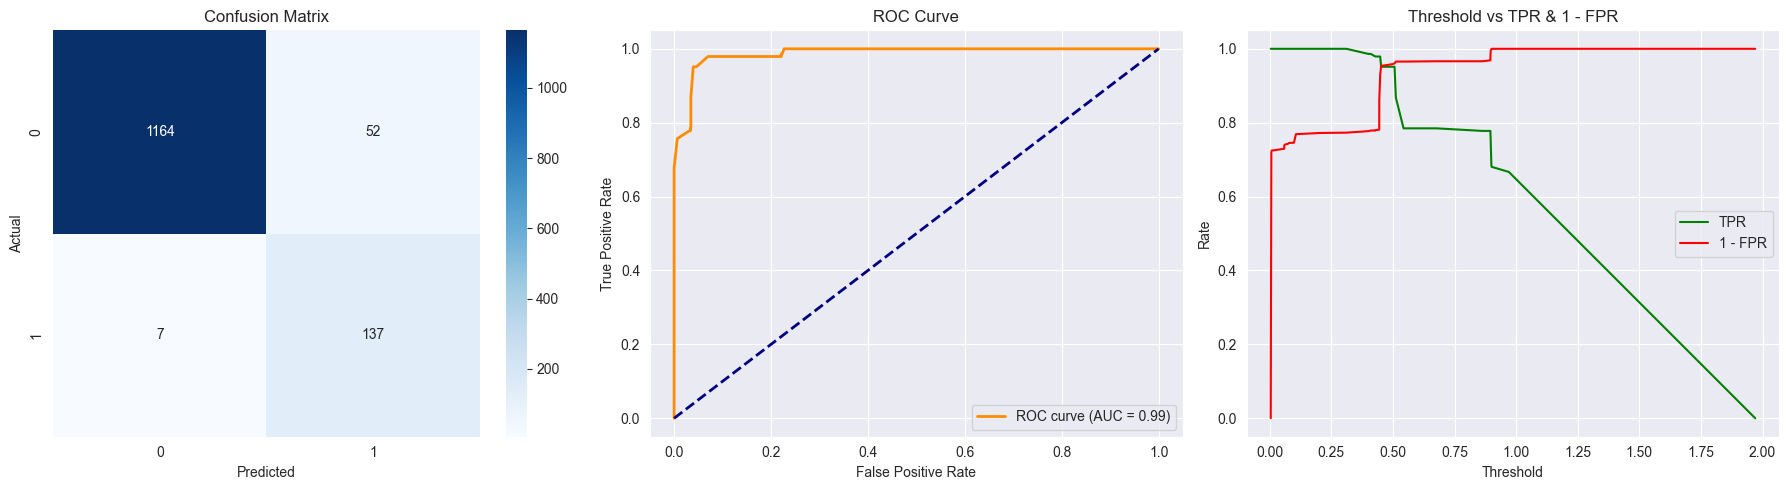

In [64]:
# comparing the results
ml_model_test_eval(rf_grid)

##### 4.3.4.2 Gradient Boosting Classifier

In [65]:
# passing all the parameters for the gradient boosting classifiers
gradBC_parameters = {

    'n_estimators': [600, 800],             # Adjusted range with good balance
    'learning_rate': [0.05, 0.1],               # Added lower LR for finer updates
    'max_depth': [4, 6, 8],                           # Better range to prevent overfitting
    'min_samples_split': [2, 5, 8],                   # Balanced split sensitivity
    'min_samples_leaf': [1, 3, 5],                    # Helps control overfitting on small branches
    'subsample': [0.7, 1.0],                    # Added more variation for bagging
    'max_features': ['sqrt', 'log2']                  # Removed None to promote feature randomness

}

In [66]:
# initializing the Gradient Boosting Classifier with gridsearchCV
gbc_grid = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid=gradBC_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
gbc_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
gbc_cv_result = pd.DataFrame.from_dict(gbc_grid.cv_results_)

# random forest best parameters
gbc_params = gbc_grid.best_params_

# saving the df as a csv for further analysis if needed
gbc_cv_result.to_csv("../models/ML_trials/gradientBoosting_model/gradient_boost_cv_results5.csv")

Fitting 4 folds for each of 432 candidates, totalling 1728 fits


In [67]:
# results for the 1st rank model
gbc_cv_result[gbc_cv_result['rank_test_score']==1]


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
192,10.533883,0.357959,0.096755,0.009242,0.05,8,log2,3,2,600,0.7,"{'learning_rate': 0.05, 'max_depth': 8, 'max_f...",0.991537,0.993653,0.997177,0.996471,0.99471,0.002257,1


In [68]:
print(gbc_params.values())

dict_values([0.05, 8, 'log2', 3, 2, 600, 0.7])


Best Parameters:
 {'learning_rate': 0.05, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 600, 'subsample': 0.7}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1216
           1       0.96      0.94      0.95       144

    accuracy                           0.99      1360
   macro avg       0.98      0.97      0.97      1360
weighted avg       0.99      0.99      0.99      1360

Accuracy: 0.9897
F1 Score: 0.951
ROC AUC Score: 0.9978


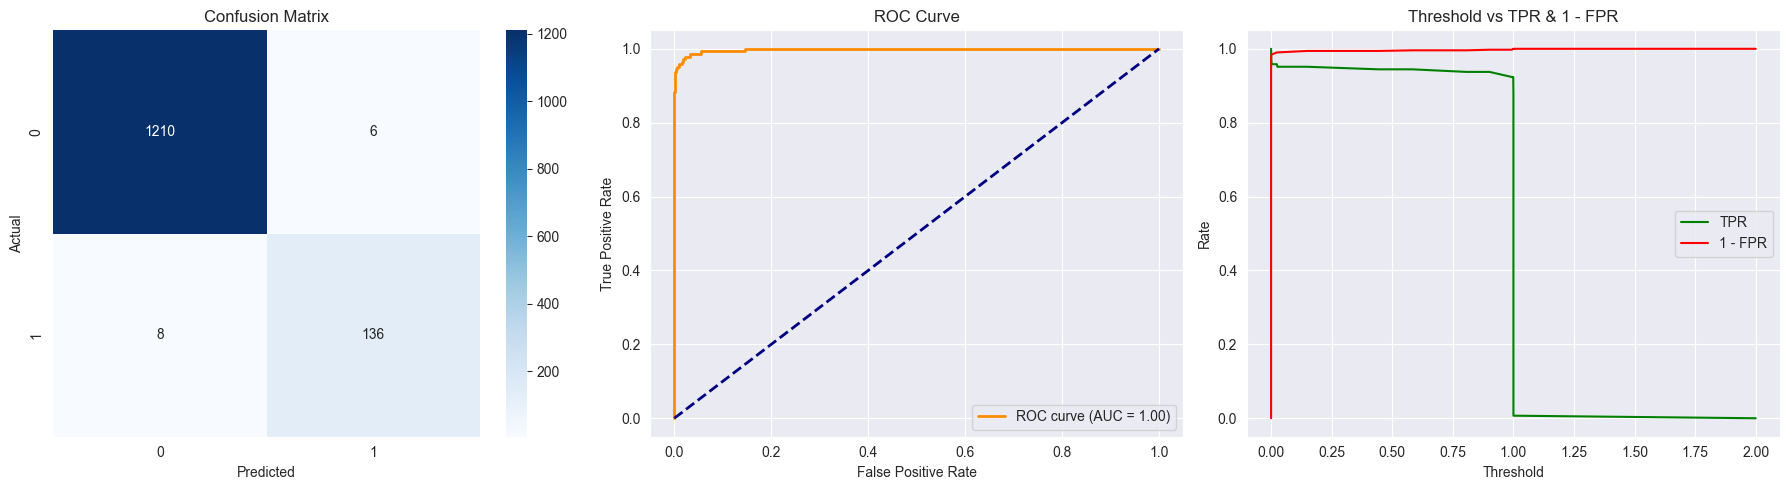

In [69]:
# Print the confusion matrix for all the above models

ml_model_test_eval(gbc_grid)

##### 4.3.4.3 CatBoost Classifier 

In [70]:
# parameters for cat boosting classifier
   
# Define base grid components
catBC_parameters =    [ {
        'iterations': [300, 500],
        'learning_rate': [0.01, 0.05],
        'depth': [6, 8],
        'bootstrap_type': ['Bayesian'],
        'bagging_temperature': [0.2, 1, 2]  # Only valid with Bayesian
    },
    {
        'iterations': [300, 500],
        'learning_rate': [0.01, 0.05],
        'depth': [6, 8],
        'bootstrap_type': ['Bernoulli'],
        'subsample': [0.6, 0.8, 1.0]       # Only valid with Bernoulli
    }
]



In [71]:
# initializing the Cat Boosting Classifier with gridsearchCV
catBC_grid = GridSearchCV(estimator=CatBoostClassifier(), param_grid=catBC_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
catBC_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
catBC_cv_result = pd.DataFrame.from_dict(catBC_grid.cv_results_)

# random forest best parameters
catBC_params = catBC_grid.best_params_

# saving the df as a csv for further analysis if needed
catBC_cv_result.to_csv("../models/ML_trials/catBoost_model/Cat_boost_cv_results5.csv")

Fitting 4 folds for each of 48 candidates, totalling 192 fits
0:	learn: 0.5753643	total: 50ms	remaining: 14.9s
1:	learn: 0.4786278	total: 66.4ms	remaining: 9.9s
2:	learn: 0.4011982	total: 81.2ms	remaining: 8.04s
3:	learn: 0.3431519	total: 101ms	remaining: 7.46s
4:	learn: 0.2932327	total: 126ms	remaining: 7.44s
5:	learn: 0.2506361	total: 153ms	remaining: 7.5s
6:	learn: 0.2180187	total: 175ms	remaining: 7.34s
7:	learn: 0.1903518	total: 193ms	remaining: 7.06s
8:	learn: 0.1681893	total: 208ms	remaining: 6.73s
9:	learn: 0.1493027	total: 224ms	remaining: 6.49s
10:	learn: 0.1347389	total: 237ms	remaining: 6.23s
11:	learn: 0.1235153	total: 250ms	remaining: 5.99s
12:	learn: 0.1110490	total: 258ms	remaining: 5.7s
13:	learn: 0.1012482	total: 267ms	remaining: 5.45s
14:	learn: 0.0937946	total: 274ms	remaining: 5.21s
15:	learn: 0.0870858	total: 282ms	remaining: 5s
16:	learn: 0.0817600	total: 290ms	remaining: 4.83s
17:	learn: 0.0769085	total: 299ms	remaining: 4.68s
18:	learn: 0.0726491	total: 307ms	r

In [72]:
# best parameters
print(catBC_params.values())

dict_values(['Bernoulli', 8, 300, 0.05, 0.8])


In [73]:
# best result 
catBC_cv_result[catBC_cv_result['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bagging_temperature,param_bootstrap_type,param_depth,param_iterations,param_learning_rate,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
40,17.46718,0.088605,0.039146,0.008531,NaN,Bernoulli,8,300,0.05,0.8,"{'bootstrap_type': 'Bernoulli', 'depth': 8, 'i...",0.991537,0.992948,0.996471,0.993648,0.993651,0.001797,1


Best Parameters:
 {'bootstrap_type': 'Bernoulli', 'depth': 8, 'iterations': 300, 'learning_rate': 0.05, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1216
           1       0.93      0.94      0.93       144

    accuracy                           0.99      1360
   macro avg       0.96      0.97      0.96      1360
weighted avg       0.99      0.99      0.99      1360

Accuracy: 0.986
F1 Score: 0.9347
ROC AUC Score: 0.998


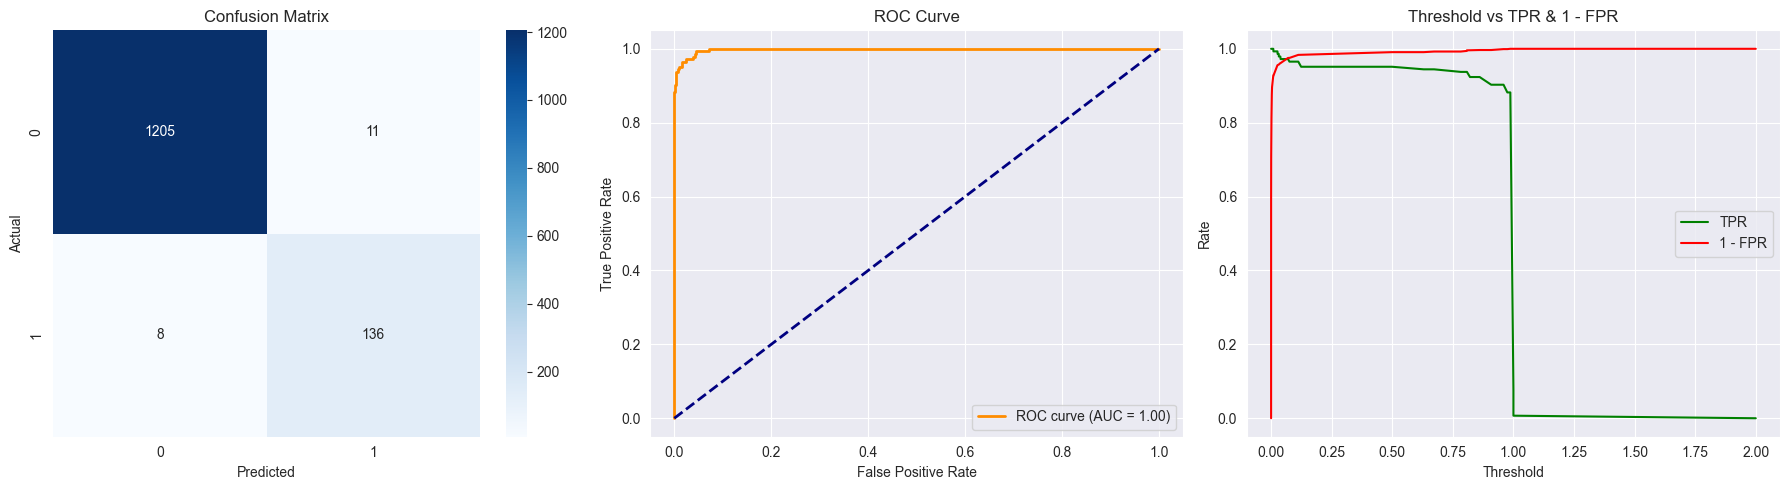

In [74]:
# evaluating the model
ml_model_test_eval(catBC_grid)

##### 4.3.4.4 Light Boosting Gradient Machine Classifier

In [75]:
# LightGBM Classifier parameters
lgbmc_parameters = {
    'n_estimators': [600, 800],             # Increased estimators for better convergence
    'learning_rate': [0.05, 0.1],               # Added smaller learning rate to improve convergence
    'max_depth': [4, 6],                            # Reduced max depth to prevent overfitting
    'num_leaves': [31, 50, 70],                       # Number of leaves slightly adjusted for efficiency
    'min_child_samples': [1, 5],                  # Lower min_child_samples for better flexibility
    'subsample': [0.7, 0.85]                   # Added more randomness to subsample to control overfitting
}

In [76]:
# initializing the Light Gradient Machine Boosting Classifier with gridsearchCV
lightgbmC_grid = GridSearchCV(estimator=LGBMClassifier(), param_grid=lgbmc_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
lightgbmC_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
lightgbmC_grid_cv_result = pd.DataFrame.from_dict(lightgbmC_grid.cv_results_)

# LGBMc best parameters
lightgbmC_grid_params = lightgbmC_grid.best_params_

# saving the df as a csv for further analysis if needed
lightgbmC_grid_cv_result.to_csv("../models/ML_trials/LightGBMC_model/lightgbmC_grid_cv_results5.csv")

Fitting 4 folds for each of 96 candidates, totalling 384 fits


In [77]:
# printing the best parameters for lightgbmc
print(lightgbmC_grid_params.values())

dict_values([0.05, 6, 1, 600, 31, 0.7])


In [78]:
# best rank results
lightgbmC_grid_cv_result[lightgbmC_grid_cv_result['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_min_child_samples,param_n_estimators,param_num_leaves,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
24,1.641728,0.634672,0.164923,0.082747,0.05,6,1,600,31,0.7,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...",0.988716,0.994358,0.998589,0.993649,0.993828,0.003504,1
25,1.658380,0.732312,0.155430,0.073724,0.05,6,1,600,31,0.85,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...",0.988716,0.994358,0.998589,0.993649,0.993828,0.003504,1


Best Parameters:
 {'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 1, 'n_estimators': 600, 'num_leaves': 31, 'subsample': 0.7}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1216
           1       0.99      0.92      0.95       144

    accuracy                           0.99      1360
   macro avg       0.99      0.96      0.97      1360
weighted avg       0.99      0.99      0.99      1360

Accuracy: 0.9904
F1 Score: 0.9534
ROC AUC Score: 0.9967


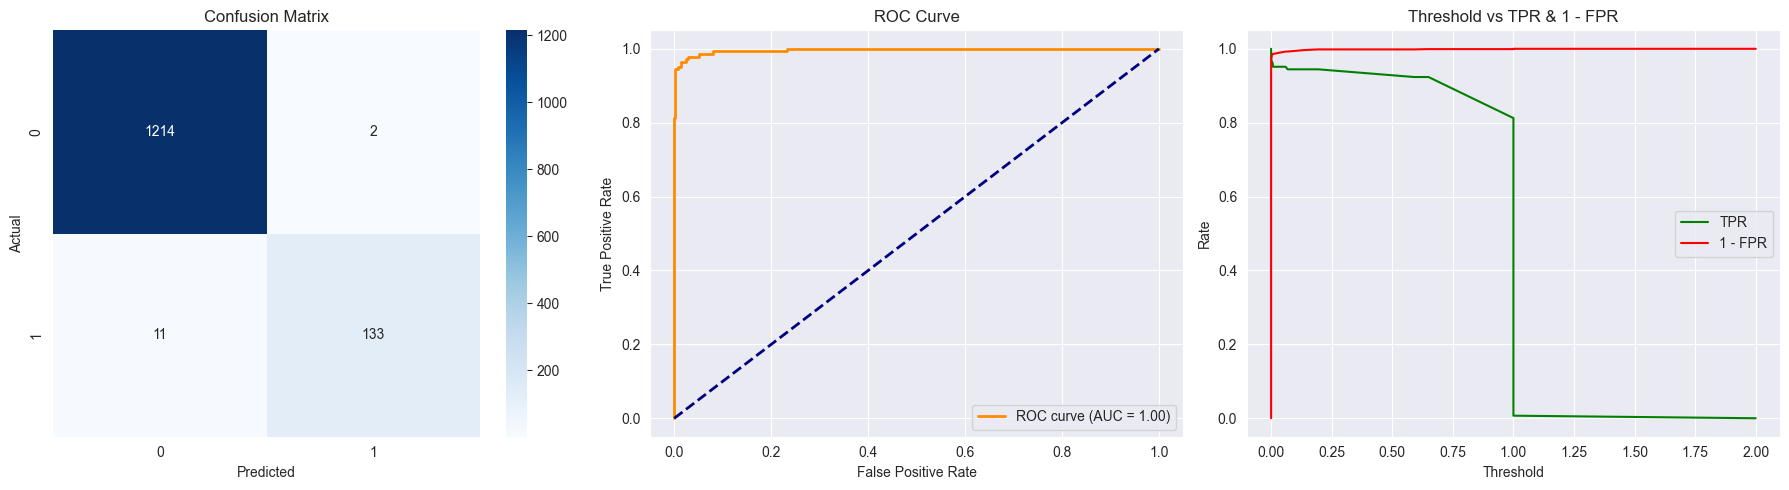

In [79]:
# metric evaluation for the model 
ml_model_test_eval(lightgbmC_grid)

##### 4.3.4.5 eXtreme Gradient Boosting Classifier

In [82]:
# eXtreme Gradient Boosting Classifiers Parameters
xgbc_parameters = {
    'learning_rate': [0.05, 0.1],              # Lower learning rate for better convergence control
    'n_estimators': [750, 900],                  # Added more variety to the number of estimators
    'max_depth': [4, 8],                            # Reduced max depth to prevent overfitting with shallow trees
    'subsample': [0.7, 1.0],                     # Adjusted subsample range for better generalization
    # 'colsample_bytree': [0.6, 0.8, 1.0],              # More feature randomness for each tree
    # 'gamma': [0.1, 0.2, 0.3],                         # Added a higher gamma value for further pruning
    'reg_lambda': [1.0, 1.5, 2.0],                    # L2 regularization, controlled for better complexity management
    'reg_alpha': [0.1, 0.5, 1.0]                      # L1 regularization, added more variety for sparsity
}

In [83]:
# initializing the eXtreme Gradient Boosting Classifier with gridsearchCV
xgbC_grid = GridSearchCV(estimator=XGBClassifier(), param_grid=xgbc_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
xgbC_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
xgbC_grid_cv_result = pd.DataFrame.from_dict(xgbC_grid.cv_results_)

# XGBcL best parameters
xgbC_grid_params = xgbC_grid.best_params_

# saving the df as a csv for further analysis if needed
xgbC_grid_cv_result.to_csv("../models/ML_trials/XGBClassifiers_model/xgbC_grid_cv_results5.csv")

Fitting 4 folds for each of 144 candidates, totalling 576 fits


In [84]:
# printing the best parameters for XGBClassifier
print(xgbC_grid_params.values())

dict_values([0.1, 8, 750, 0.1, 1.0, 1.0])


In [85]:
# xgbClassifiers rank 1 scores and its parameters
xgbC_grid_cv_result[xgbC_grid_cv_result['rank_test_score']==1]


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
109,4.76052,0.496051,0.037253,0.001302,0.1,8,750,0.1,1.0,1.0,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti...",0.988716,0.995063,0.996471,0.992237,0.993122,0.002966,1


Best Parameters:
 {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 750, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1216
           1       0.94      0.94      0.94       144

    accuracy                           0.99      1360
   macro avg       0.97      0.97      0.97      1360
weighted avg       0.99      0.99      0.99      1360

Accuracy: 0.9875
F1 Score: 0.9412
ROC AUC Score: 0.9981


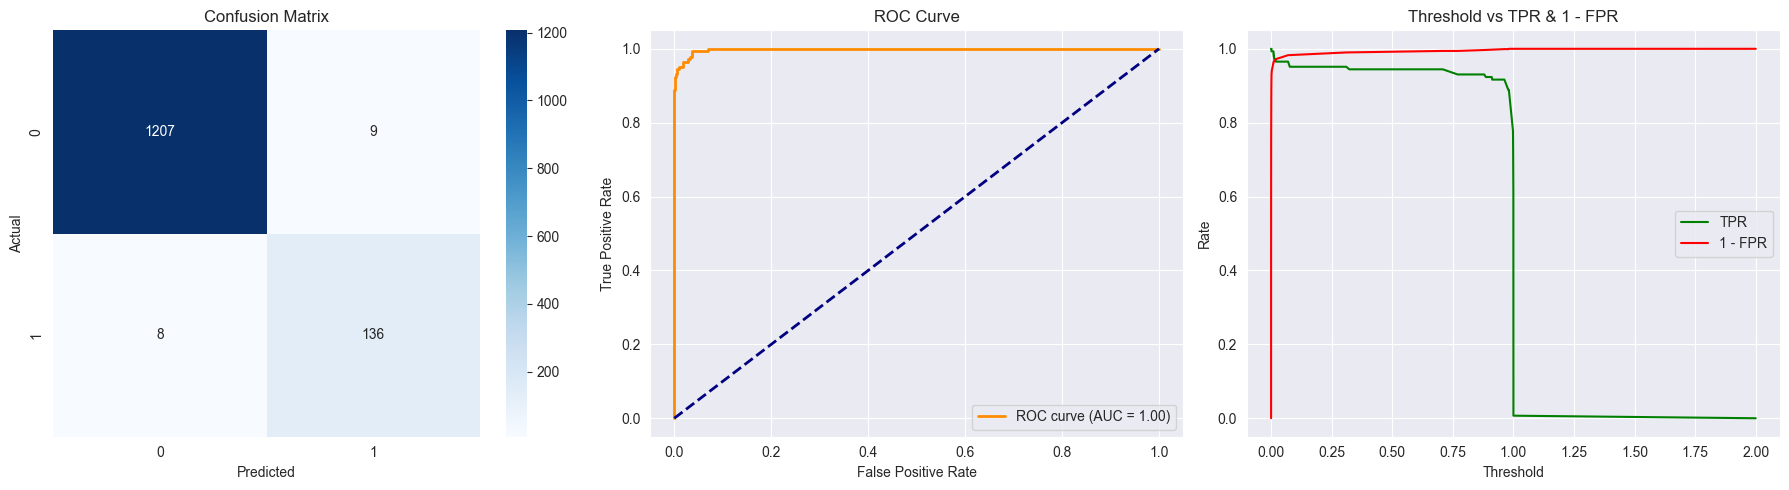

In [86]:
ml_model_test_eval(xgbC_grid)

##### 4.3.4.6 eXtreme Gradient Boosting Random Forest Classifier

In [87]:
# Xtreme Gradient Boosting Random FOrest Classifiers
xgbrfC_parameters = {
    'n_estimators': [600, 800, 1000],                   # Optimized number of estimators for performance balance
    'max_depth': [3, 5, 7],                             # Added intermediate depth for more flexibility
    'learning_rate': [0.05, 0.1],                # Lower learning rate options for better fine-tuning
    'colsample_bytree': [0.5, 1.0],               # Range of feature subsample to promote diversity in trees
    'subsample': [0.5, 1.0],                      # Introduced intermediate subsample values for more flexibility
    'min_child_weight': [1, 3, 5],                      # Broader range to control overfitting (lower values avoid pruning)
    'gamma': [0.1, 0.3],                            # Expanded gamma for better tree pruning
    'reg_lambda': [1.0, 1.5]                     # L2 regularization for controlling model complexity
}

In [88]:
# initializing the eXtreme Gradient Boosting Classifier with gridsearchCV
xgbrfC_grid = GridSearchCV(estimator=XGBRFClassifier(), param_grid=xgbrfC_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
xgbrfC_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
xgbrfC_grid_cv_result = pd.DataFrame.from_dict(xgbrfC_grid.cv_results_)

# Xtremem gradient Boosting random forest best parameters
xgbrfC_grid_params = xgbrfC_grid.best_params_

# saving the df as a csv for further analysis if needed
xgbrfC_grid_cv_result.to_csv("../models/ML_trials/XGBRFClassifiers_model/xgbrfC_grid_cv_results5.csv")

Fitting 4 folds for each of 864 candidates, totalling 3456 fits


In [89]:
# printing the best parameters for XGBRFClassifier
print(xgbrfC_grid_params.values())

dict_values([1.0, 0.1, 0.05, 7, 1, 800, 1.0, 1.0])


In [90]:
# xgbrfClassifiers rank 1 scores and its parameters
xgbrfC_grid_cv_result[xgbrfC_grid_cv_result['rank_test_score']==1]


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
509,5.467334,0.641332,0.049876,0.014709,1.0,0.1,0.05,7,1,800,1.0,1.0,"{'colsample_bytree': 1.0, 'gamma': 0.1, 'learn...",0.978842,0.984485,0.992943,0.983768,0.98501,0.005069,1
617,5.959286,0.217252,0.049397,0.001936,1.0,0.1,0.1,7,1,800,1.0,1.0,"{'colsample_bytree': 1.0, 'gamma': 0.1, 'learn...",0.978842,0.984485,0.992943,0.983768,0.98501,0.005069,1
725,5.457150,0.630006,0.042859,0.004099,1.0,0.3,0.05,7,1,800,1.0,1.0,"{'colsample_bytree': 1.0, 'gamma': 0.3, 'learn...",0.978842,0.984485,0.992943,0.983768,0.98501,0.005069,1
833,5.971533,0.155609,0.050637,0.006222,1.0,0.3,0.1,7,1,800,1.0,1.0,"{'colsample_bytree': 1.0, 'gamma': 0.3, 'learn...",0.978842,0.984485,0.992943,0.983768,0.98501,0.005069,1


Best Parameters:
 {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 800, 'reg_lambda': 1.0, 'subsample': 1.0}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1216
           1       0.87      0.94      0.91       144

    accuracy                           0.98      1360
   macro avg       0.93      0.96      0.95      1360
weighted avg       0.98      0.98      0.98      1360

Accuracy: 0.9794
F1 Score: 0.9067
ROC AUC Score: 0.9973


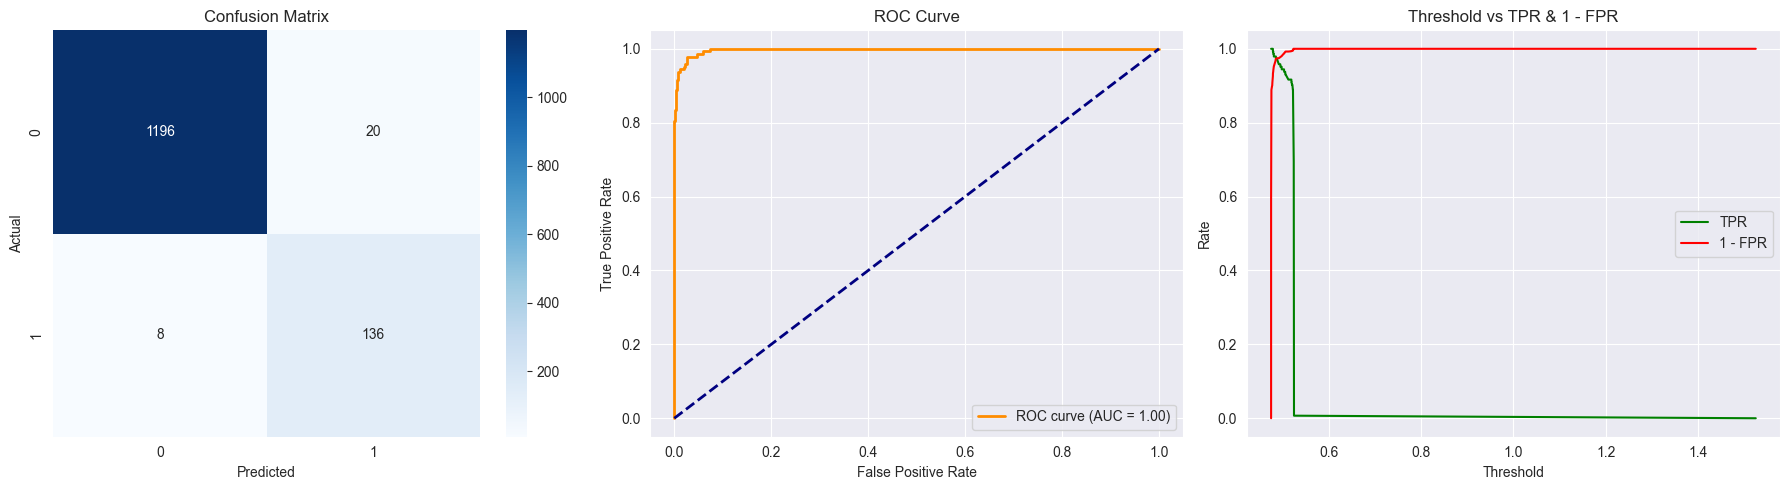

In [91]:
ml_model_test_eval(xgbrfC_grid)

### 4.4 Final ML Model

In [92]:
for model_name , score in final_ML_model.items():
    print(f"Model Name : {model_name} , F1_score : {score}")

Model Name : RandomForestClassifier , F1_score : 0.8228228228228228
Model Name : GradientBoostingClassifier , F1_score : 0.951048951048951
Model Name : CatBoostClassifier , F1_score : 0.9347079037800687
Model Name : LGBMClassifier , F1_score : 0.953405017921147
Model Name : XGBClassifier , F1_score : 0.9411764705882353
Model Name : XGBRFClassifier , F1_score : 0.9066666666666667


In [93]:
# final machine learning models list 
final_ML_model_df = pd.DataFrame.from_dict(final_ML_model, orient='index')
final_ML_model_df

,0
RandomForestClassifier,0.822823
GradientBoostingClassifier,0.951049
CatBoostClassifier,0.934708
LGBMClassifier,0.953405
XGBClassifier,0.941176
XGBRFClassifier,0.906667


From the above output we can see that the higher test accuracies belongs to 
* `Gradient Boosting`= **95.10**% , 
* `Light Gradient Boosting Machine` = **95.34**%

So I personally think LGBMClassifier is overfitting from the graphs shown therefore better model would be `Gradient Boosting Classifier`

#### 4.4.1 Initializing the FINAL model 

In [94]:
# best parameters of the chosen model (Gradient Boosting Classifier)
gbc_params

{'learning_rate': 0.05,
 'max_depth': 8,
 'max_features': 'log2',
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 600,
 'subsample': 0.7}

In [95]:
# training the catboost model with the best parameters 
Grad_boost_official = GradientBoostingClassifier(
    learning_rate = 0.05,         # Already a small value — good for reducing overfitting
    n_estimators = 600,           # Total number of boosting stages
    max_depth = 8,                # Controls the complexity of each individual tree
    min_samples_split = 2,        # Minimum samples required to split a node
    min_samples_leaf = 3,         # Minimum samples at a leaf node
    subsample = 0.7,              # Random fraction of data for training each tree (reduces variance)
    max_features = 'log2',        # Reduces correlation between trees

    # Additional parameters to help control overfitting:
    validation_fraction = 0.1,    # Portion of training data to set aside as validation
    n_iter_no_change = 10,        # Stops training if no improvement in 'n' rounds (early stopping)
    tol = 1e-4,                   # Tolerance for early stopping
    ccp_alpha = 0.001,            # Complexity parameter for Minimal Cost-Complexity Pruning
    random_state = 42             # For reproducibility
)

'''
I have also altered some parameters and increased some values.
'''

# fitting the model with the train set
Grad_boost_official.fit( X_train_resampled, y_train_resampled )



GradientBoostingClassifier(ccp_alpha=0.001, learning_rate=0.05, max_depth=8,
                           max_features='log2', min_samples_leaf=3,
                           n_estimators=600, n_iter_no_change=10,
                           random_state=42, subsample=0.7)

#### 4.4.2 Validating the final model

In [97]:
# predicting and validating the resutls of th y_hat
y_predict_OFF = Grad_boost_official.predict(X_test_processed)

# accuracies and F1_scores for the model
accuracy_OFF = accuracy_score(y_test, y_predict_OFF)
f1_score_OFF = f1_score(y_test, y_predict_OFF)

# printing the accuracies for the model prediction
print(f"Accuracy of Gradient Boosting ML Model : {accuracy_OFF}")
print(f"F1 Score of Gradient Boosting ML Model : {f1_score_OFF}")

Accuracy of Gradient Boosting ML Model : 0.9735294117647059
F1 Score of Gradient Boosting ML Model : 0.883116883116883


#### 4.4.3 Model Save

In [98]:
# saving the model 

# Create directory if it doesn't exist
folder_path = "../models/final_model"
os.makedirs(folder_path, exist_ok=True)

# Save path
file_path = os.path.join(folder_path, "personal_loan_ML_grad_boost_model.pkl")

# Save the model
joblib.dump(model, file_path)

['../models/final_model\\personal_loan_ML_grad_boost_model.pkl']

### 4.5 Model Training (NN)/(DL)

#### 4.5.1 Hyperparameter Tuning for Best NN model

In [99]:
# function for NN model tuning 

# functino initialization
def build_model(hp):
    # model initializing
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(X_train_resampled.shape[1],)))

    # Tunable hidden layers — up to 4 layers
    num_layers = hp.Int('num_layers', min_value=1, max_value=4, step=1)

    for i in range(num_layers):
        # units , activation functions, regularizers options choice LIST 
        units = hp.Int(f'units_{i}', min_value=64, max_value=512, step=64)
        activation_choice = hp.Choice(f'activation_{i}', ['relu', 'swish', 'leaky_relu'])
        l2_reg = hp.Float(f'l2_reg_{i}', min_value=1e-5, max_value=1e-2, sampling='log')

        # Dense layer without activation
        model.add(tf.keras.layers.Dense(units=units,
                               activation=None,
                               kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))

        # Activation layer based on choice
        if activation_choice == 'leaky_relu':
            model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
        else:
            model.add(tf.keras.layers.Activation(activation_choice))

        # Add Dropout **only once after second layer**
        if i == 1:
            if hp.Boolean('add_dropout'):
                dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
                model.add(tf.keras.layers.Dropout(rate=dropout_rate))

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Compile the model with tunable optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam', 'nadam'])
    optimizer = tf.keras.optimizers.get(optimizer_choice)

    # initiating the model 
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [104]:
# Tuner initializing 
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=25,
    factor=3,
    directory="../models/NN_model trials",
    project_name='personal_loan_NN_test4',
    overwrite=True
)

In [105]:
print(tuner)

#### 4.5.2 Fit trainset for Tuning 

In [106]:
    # early stopping for preventing wasting time and wasting unwanted trials
# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)


In [107]:
# Run hyperparameter search
tuner.search(X_train_resampled, y_train_resampled, epochs=25, validation_data=(X_test_processed, y_test), 
             verbose=1, callbacks=[early_stopping])



Trial 30 Complete [00h 00m 12s]
val_accuracy: 0.9786764979362488

Best val_accuracy So Far: 0.9852941036224365
Total elapsed time: 00h 04m 29s
INFO:tensorflow:Oracle triggered exit


In [108]:
# Get the best hyperparameters
best_NN_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# printing the best hyper parameters for the neural network
print(best_NN_hps.values)

{'num_layers': 4, 'units_0': 320, 'activation_0': 'relu', 'l2_reg_0': 2.355343925247565e-05, 'optimizer': 'adam', 'units_1': 128, 'activation_1': 'relu', 'l2_reg_1': 2.945751609120569e-05, 'add_dropout': True, 'dropout_rate': 0.30000000000000004, 'units_2': 448, 'activation_2': 'relu', 'l2_reg_2': 0.0009969653267339197, 'units_3': 384, 'activation_3': 'swish', 'l2_reg_3': 0.00010868800321098675, 'tuner/epochs': 25, 'tuner/initial_epoch': 9, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


In [109]:
for i , j in best_NN_hps.values.items():
    print(f"{i} ->\t {j}")

num_layers ->	 4
units_0 ->	 320
activation_0 ->	 relu
l2_reg_0 ->	 2.355343925247565e-05
optimizer ->	 adam
units_1 ->	 128
activation_1 ->	 relu
l2_reg_1 ->	 2.945751609120569e-05
add_dropout ->	 True
dropout_rate ->	 0.30000000000000004
units_2 ->	 448
activation_2 ->	 relu
l2_reg_2 ->	 0.0009969653267339197
units_3 ->	 384
activation_3 ->	 swish
l2_reg_3 ->	 0.00010868800321098675
tuner/epochs ->	 25
tuner/initial_epoch ->	 9
tuner/bracket ->	 2
tuner/round ->	 2
tuner/trial_id ->	 0012


#### 4.5.3 Training the best neural network model 

In [110]:

# Build and train the best model
best_NN_model = tuner.hypermodel.build(best_NN_hps)
best_NN_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=120,
    batch_size=32,  #  32 batch_size for better generalization, I hope 
    validation_data=(X_test_processed, y_test),
    verbose=2
)

Epoch 1/120
178/178 - 3s - loss: 0.2813 - accuracy: 0.9425 - val_loss: 0.1757 - val_accuracy: 0.9632 - 3s/epoch - 15ms/step
Epoch 2/120
178/178 - 1s - loss: 0.1340 - accuracy: 0.9711 - val_loss: 0.1513 - val_accuracy: 0.9625 - 1s/epoch - 6ms/step
Epoch 3/120
178/178 - 1s - loss: 0.0968 - accuracy: 0.9771 - val_loss: 0.1304 - val_accuracy: 0.9618 - 958ms/epoch - 5ms/step
Epoch 4/120
178/178 - 1s - loss: 0.0764 - accuracy: 0.9799 - val_loss: 0.1092 - val_accuracy: 0.9787 - 946ms/epoch - 5ms/step
Epoch 5/120
178/178 - 1s - loss: 0.0729 - accuracy: 0.9783 - val_loss: 0.1190 - val_accuracy: 0.9662 - 1s/epoch - 6ms/step
Epoch 6/120
178/178 - 1s - loss: 0.0620 - accuracy: 0.9808 - val_loss: 0.1348 - val_accuracy: 0.9551 - 1s/epoch - 6ms/step
Epoch 7/120
178/178 - 1s - loss: 0.0564 - accuracy: 0.9845 - val_loss: 0.1010 - val_accuracy: 0.9713 - 1s/epoch - 7ms/step
Epoch 8/120
178/178 - 1s - loss: 0.0520 - accuracy: 0.9854 - val_loss: 0.0926 - val_accuracy: 0.9750 - 1s/epoch - 6ms/step
Epoch 9/1

In [111]:
# saving the final neural network model
best_NN_model.save("../models/final_model/personal_loan_NN_model2.keras")

## Task 5 : Which Model? 

In [ ]:
# Give your reasoning on which is the best model in this case and why it performs better

While Comparing both the **Machine Learning** and **Deep Learning** Models:
 
* it turns out that Deep Learning MOdel works better with even better accuracies of 
* above **97**% whereas 
* the ML algorithm that finally got chosen was `Cat Boosting Classifier` 
* with **95.37**% accuracy 
* overall the neural network model performed better with `Tensorflow`